In [1]:
# Telco customer churn - full analysis, from the raw CSV to a saved model.
# Business question: which customers are about to leave, 
# while there is still time to call them?

# 1. Setup and data loading
import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib


telco_df = pd.read_csv("../data/TelcoCustomerChurn.csv")   # 7,043 customers, one row each
telco_df.head()   # first 5 rows, to confirm the file loaded and the columns look right

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
telco_df.info()   # column types and how many values are actually filled in

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Two columns came in with the wrong type, so fix them before anything else.

# SeniorCitizen is a 0/1 flag, not a quantity - boolean stops anyone averaging it
telco_df['SeniorCitizen'] = telco_df['SeniorCitizen'].astype('boolean')

# TotalCharges came in as text because a few rows hold a blank space instead of a number.
# errors='coerce' turns those blanks into NaN so the missing-value check below catches them.
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

telco_df.info()   # both columns should read as boolean and float now

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   boolean
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Missing-value check. A blank space is missing data too, so count it alongside NaN.
(telco_df.isnull() | (telco_df == ' ')).sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: Int64

In [5]:
# Check who the customers with empty TotalCharges are before deciding on a fill value.
telco_df[telco_df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,False,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,False,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,False,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,False,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,False,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,False,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
# All of them have tenure 0 - new customers who have not been billed yet,
# so 0 is the right fill here rather than a mean or a guess.
telco_df['TotalCharges'] = telco_df['TotalCharges'].fillna(0)

(telco_df.isnull() | (telco_df == ' ')).sum()   # re-check: nothing missing now

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: Int64

In [7]:
telco_df.duplicated().sum()   # any customer recorded twice? 0 means every row is unique

np.int64(0)

In [8]:
# No duplicate records found.

# -------------
# Sort the columns by the job they do: identifier, target, numeric feature, categorical feature
# -------------
# customerID : an identifier, never a feature - the tree would just memorise it
# Churn      : the thing we are trying to predict

id_and_target_columns = ['customerID', 'Churn']

raw_numeric_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# whatever is left is categorical (contract type, payment method, the service flags, ...)
raw_categorical_columns = [
    col for col in telco_df.columns
    if (col not in raw_numeric_columns and
       col not in id_and_target_columns)
]

print("Id column: customerID \n  [Id column can not be feature due to overfitting & Zero Generalisation]")
print("\nTarget: Churn \n  [Target which we want to predict]")
print("\nNumerical features:")
print(raw_numeric_columns)
print("\nCategorical features:")
print(raw_categorical_columns)

Id column: customerID 
  [Id column can not be feature due to overfitting & Zero Generalisation]

Target: Churn 
  [Target which we want to predict]

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
# How balanced is the target? This decides which metrics are worth trusting later.
# Roughly one customer in four churned, so accuracy alone would flatter a model that
# just predicts "No" every time.
churn_balance = pd.DataFrame({
    'Count': telco_df['Churn'].value_counts(),
    'Percentage': telco_df['Churn'].value_counts(normalize=True) * 100
})

churn_balance

,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


In [10]:
# -------------
# Split the data before any model sees it
# Train/Test split: 70:30
# Random seed: 42, so the same rows land in the same half on every run
# -------------

# The cleaning above only fixed types and blanks - nothing fitted on the rows -
# so running it on the full table does not leak test data into training.

features = telco_df.drop(['customerID', 'Churn'], axis=1)   # everything the model is allowed to look at
target = telco_df['Churn'].map({'Yes': 1, 'No': 0})         # 1 = the customer left

# stratify keeps the same churn rate in both halves, which matters with an imbalanced target
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.30, random_state=42, stratify=target
)

Visualization 1: Customer vs Churn Distribution



[Text(0, 0, '5174'), Text(0, 0, '1869')]

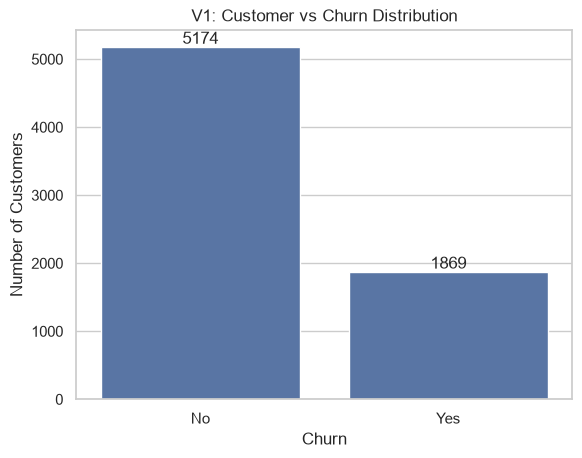

In [11]:
# 2. Exploratory Data Analysis
sns.set_theme(style="whitegrid")

# Chart 1: how many customers stayed vs left - the baseline for the charts below
print("Visualization 1: Customer vs Churn Distribution\n")

churn_count_plot = sns.countplot(data=telco_df, x='Churn')
churn_count_plot.set_title('V1: Customer vs Churn Distribution')
churn_count_plot.set_ylabel('Number of Customers')
churn_count_plot.bar_label(churn_count_plot.containers[0])


Visualization 2: Customer Churn by Contract Type



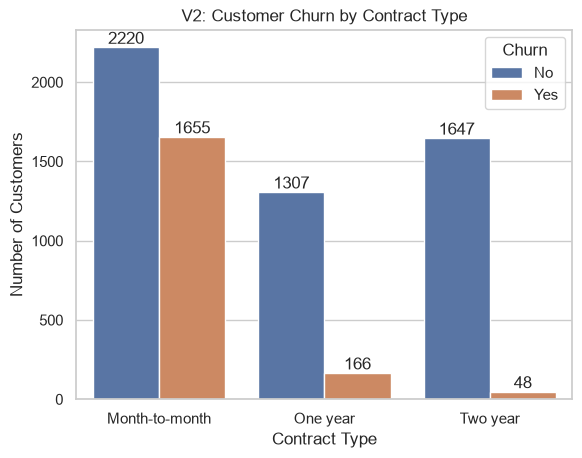

In [12]:
print("\nVisualization 2: Customer Churn by Contract Type\n")

# Chart 2: contract type. Month-to-month customers can leave any month, and they do.
contract_churn_plot = sns.countplot(data=telco_df, x='Contract', hue='Churn')
contract_churn_plot.set_title('V2: Customer Churn by Contract Type')
contract_churn_plot.set_xlabel('Contract Type')
contract_churn_plot.set_ylabel('Number of Customers')
#contract_churn_plot.bar_label(contract_churn_plot.containers[0])
for bar_group in contract_churn_plot.containers:
    contract_churn_plot.bar_label(bar_group)



Visualization 3: Customer Churn by Internet Service



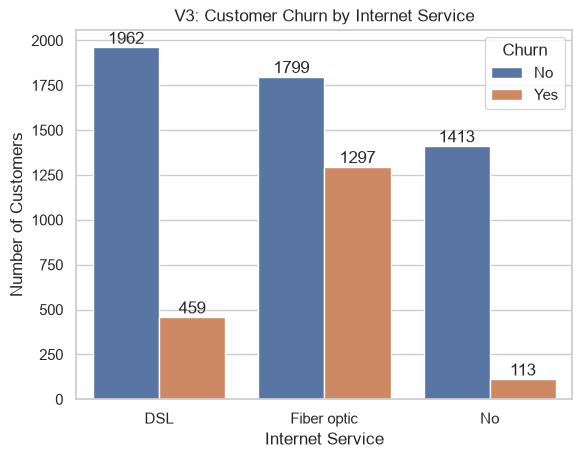

In [13]:
print("\nVisualization 3: Customer Churn by Internet Service\n")

# Chart 3: internet service. Fiber optic customers pay the most and leave the most.
internet_churn_plot = sns.countplot(data=telco_df, x='InternetService', hue='Churn')
internet_churn_plot.set_title('V3: Customer Churn by Internet Service')
internet_churn_plot.set_xlabel('Internet Service')
internet_churn_plot.set_ylabel('Number of Customers')
#internet_churn_plot.bar_label(internet_churn_plot.containers[0])
for bar_group in internet_churn_plot.containers:
    internet_churn_plot.bar_label(bar_group)


Visualization 4: Churn vs Tenure



Text(0, 0.5, 'Number of Customers')

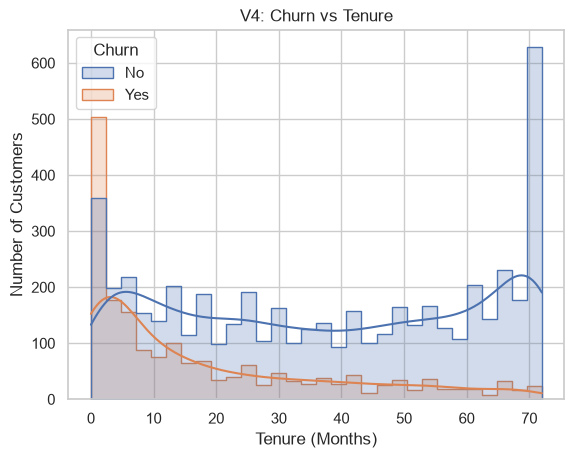

In [14]:
print("\nVisualization 4: Churn vs Tenure\n")

# Chart 4: how long customers stay. Most churn falls in the first few months,
# and drops off once a customer is past the first year.
tenure_churn_plot = sns.histplot(
    data=telco_df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    element='step'
)
tenure_churn_plot.set_title('V4: Churn vs Tenure')
tenure_churn_plot.set_xlabel('Tenure (Months)')
tenure_churn_plot.set_ylabel('Number of Customers')


Visualization 5: Monthly Charges by Churn



Text(25.64127604166667, 0.5, 'Churn')

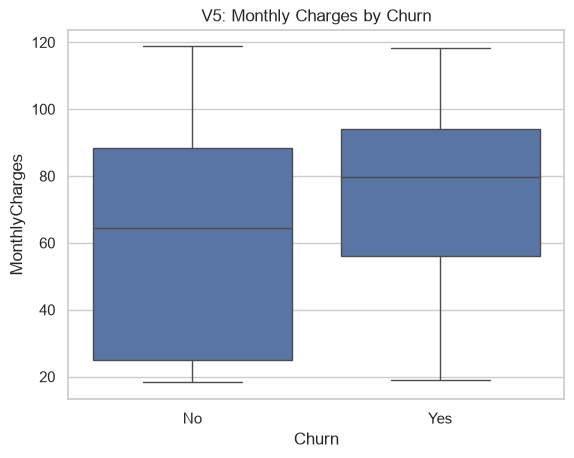

In [15]:
print("\nVisualization 5: Monthly Charges by Churn\n")

# 5. Monthly Charges by Churn
monthly_charges_by_churn = sns.boxplot (
    data=telco_df,
    x='Churn',
    y='MonthlyCharges'
)
monthly_charges_by_churn.set_title('V5: Monthly Charges by Churn')
tenure_churn_plot.set_xlabel('Monthly Charges')
tenure_churn_plot.set_ylabel('Churn')


Visualization 6: Customer Churn by Payment Method



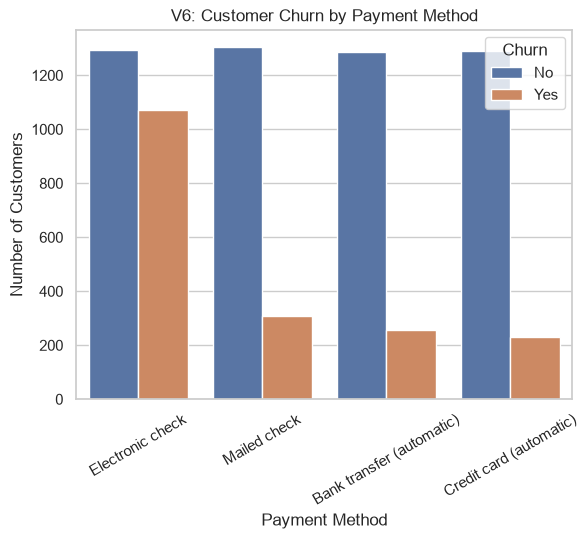

In [16]:
print("\nVisualization 6: Customer Churn by Payment Method\n")

# 6. Customer Churn by Payment Method
customer_churn_by_payment_method = sns.countplot (
    data=telco_df,
    x='PaymentMethod',
    hue='Churn'
)
customer_churn_by_payment_method.set_title('V6: Customer Churn by Payment Method')
customer_churn_by_payment_method.set_xlabel('Payment Method')
customer_churn_by_payment_method.set_ylabel('Number of Customers')
customer_churn_by_payment_method.tick_params(axis='x', rotation=30)

In [17]:
## 3. Feature Engineering
# Three things the raw columns do not state directly:
#   1. SpendPerService - what the customer pays for each product they actually hold
#   2. AvgMonthlySpend - the average bill across the whole relationship, not just this month
#   3. IsAutoPay       - is the bill paid automatically, or does it need a decision every month

# 1. The feature rules live in a module rather than in this cell on purpose: saving a model
#    stores a reference to the class, not its code, so app.py has to import the same class
#    before it can load the model back.
sys.path.append(os.path.abspath('..'))   # the notebook runs from notebook/, so put the project root on the import path
from churn_features import ChurnFeatureAdder

# 2. Column lists for the encoder, named for the columns as they look AFTER that step runs.
#    tenure belongs in this list - it is one of the strongest predictors in the data, so it
#    must reach the model instead of being dropped.
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SpendPerService', 'AvgMonthlySpend']
binary_features = ['SeniorCitizen', 'IsAutoPay']

# Everything left over is categorical: contract type, payment method, the service flags.
# X_train still holds the raw columns here, so the engineered ones are simply not in it yet.
categorical_features = [col for col in X_train.columns
                        if col not in numerical_features + binary_features]

# 3. A decision tree can only compare numbers, so the text columns have to become numbers first.
#    One-hot encoding turns Contract into three 0/1 columns, one per possible value, so no
#    accidental ordering is implied between them.
#    handle_unknown='ignore' encodes a value never seen during training as all zeros instead
#    of raising, which is what keeps the API from failing on an odd request.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'   # numeric and binary columns are already numbers, so leave them untouched
)

# Add the features, then encode, as one unit - training data and live requests then go
# through identical preparation. Repeating these steps by hand is easy to get subtly wrong.
data_pipeline = Pipeline([
    ('feature_engineer', ChurnFeatureAdder()),
    ('preprocessor', preprocessor)
])

# fit_transform learns the encoding and applies it; transform only applies what was already
# learnt. Fitting on the test set would leak the data the model is about to be scored on.
X_train_encoded = data_pipeline.fit_transform(X_train)
X_test_encoded = data_pipeline.transform(X_test)

In [18]:
# Sanity check: this is the table the model actually sees, one column per encoded category
encoded_feature_names = preprocessor.get_feature_names_out()
encoded_train_preview = pd.DataFrame(X_train_encoded, columns=encoded_feature_names)
encoded_train_preview.head()

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__SpendPerService,remainder__AvgMonthlySpend,remainder__IsAutoPay
0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,False,5,80.2,384.25,40.1,76.85,0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,True,3,86.85,220.95,28.95,73.65,0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,False,3,75.15,216.75,37.575,72.25,1
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,False,60,80.55,4847.05,13.425,80.784167,1
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,False,12,98.9,1120.95,19.78,93.4125,1


In [19]:
## 4. Model Development
# Same data and same seed for all three trees - only the amount of freedom changes.

# Model 1: no limits. Grows until every leaf is pure, which overfits.
tree_unpruned = DecisionTreeClassifier(random_state=42)
tree_unpruned.fit(X_train_encoded, y_train)
pred_unpruned = tree_unpruned.predict(X_test_encoded)

# Model 2: shallow and pruned. Short enough to read, and has to rely on the strong signals.
tree_depth5 = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
tree_depth5.fit(X_train_encoded, y_train)
pred_depth5 = tree_depth5.predict(X_test_encoded)

# Model 3: twice the depth of model 2, to check whether more splits actually help.
tree_depth10 = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
tree_depth10.fit(X_train_encoded, y_train)
pred_depth10 = tree_depth10.predict(X_test_encoded)

# 5. Model Evaluation
# All four metrics side by side. Recall is the one to watch: of the customers who did leave,
# how many did we flag in time?
model_comparison = pd.DataFrame({
    'Model': ['Decision Tree 1', 'Decision Tree 2', 'Decision Tree 3'],
    'Accuracy': [accuracy_score(y_test, pred_unpruned), accuracy_score(y_test, pred_depth5), accuracy_score(y_test, pred_depth10)],
    'Precision': [precision_score(y_test, pred_unpruned), precision_score(y_test, pred_depth5), precision_score(y_test, pred_depth10)],
    'Recall': [recall_score(y_test, pred_unpruned), recall_score(y_test, pred_depth5), recall_score(y_test, pred_depth10)],
    'F1 Score': [f1_score(y_test, pred_unpruned), f1_score(y_test, pred_depth5), f1_score(y_test, pred_depth10)],
    'Confusion Matrix': [confusion_matrix(y_test, pred_unpruned), confusion_matrix(y_test, pred_depth5), confusion_matrix(y_test, pred_depth10)],
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Decision Tree 1,0.734027,0.499151,0.524064,0.511304,"[[1257, 295], [267, 294]]"
1,Decision Tree 2,0.791292,0.608303,0.600713,0.604484,"[[1335, 217], [224, 337]]"
2,Decision Tree 3,0.761950,0.556420,0.509804,0.532093,"[[1324, 228], [275, 286]]"


In [20]:
## 6. Hyperparameter tuning
# Sections 4 and 5 picked DT2 by comparing test scores, which is not a safe way to choose:
# once the test set has helped select the model it is no longer an untouched estimate of how
# the model behaves on new customers. GridSearchCV fixes that. It scores every candidate with
# 5-fold cross-validation inside the TRAINING set only, so the test set stays reserved for the
# single final check at the end.

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Scoring on f1 rather than accuracy: at a 26.5% churn rate accuracy rewards a model that
# simply answers "No" every time, while f1 only goes up if precision and recall both hold up.
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv_folds,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_encoded, y_train)   # training folds only, the test set is not touched

print("Combinations tried:", len(grid_search.cv_results_['params']))
print("Best parameters   :", grid_search.best_params_)
print("Best CV f1 score  : %.4f" % grid_search.best_score_)

# The five strongest settings side by side, to see how much the choice actually moves the score
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[['param_criterion', 'param_max_depth', 'param_min_samples_leaf',
            'param_min_samples_split', 'mean_test_score', 'std_test_score']] \
    .sort_values('mean_test_score', ascending=False).head()


Combinations tried: 224
Best parameters   : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best CV f1 score  : 0.5862


,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,mean_test_score,std_test_score
43,gini,5,10,50,0.586248,0.025902
41,gini,5,10,10,0.585834,0.025484
42,gini,5,10,20,0.585834,0.025484
40,gini,5,10,2,0.585834,0.025484
35,gini,5,1,50,0.584154,0.024633


In [21]:
## 7. Handling class imbalance
# Roughly three customers stayed for every one who left, so the tree sees far more examples of
# staying and leans that way. class_weight='balanced' scales each class by its inverse frequency,
# which makes one churn row count about three times as much as a stay row during training.
# Same grid and same folds as section 6, so weighting is the only thing that changes.

grid_search_balanced = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=cv_folds,
    scoring='f1',
    n_jobs=-1
)
grid_search_balanced.fit(X_train_encoded, y_train)

print("Balanced best parameters:", grid_search_balanced.best_params_)
print("Balanced best CV f1     : %.4f" % grid_search_balanced.best_score_)

tuned_tree = grid_search.best_estimator_
tuned_tree_balanced = grid_search_balanced.best_estimator_


def score_model(label, model, X_eval=None):
    """One row of test-set metrics, including the two that do not depend on the cutoff."""
    X_eval = X_test_encoded if X_eval is None else X_eval
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'ROC AUC': roc_auc_score(y_test, probabilities),
        'PR AUC': average_precision_score(y_test, probabilities)
    }


pd.DataFrame([
    score_model('Tuned tree (no weighting)', tuned_tree),
    score_model('Tuned tree (balanced)', tuned_tree_balanced)
]).round(3)


Balanced best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Balanced best CV f1     : 0.6222


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Tuned tree (no weighting),0.794,0.615,0.602,0.608,0.828,0.623
1,Tuned tree (balanced),0.695,0.459,0.841,0.594,0.830,0.618


In [22]:
# Weighting is not the only way to trade precision against recall. The API turns a probability
# into a Yes/No at CHURN_THRESHOLD, so moving that cutoff does the same job with no retraining.
churn_probabilities = tuned_tree.predict_proba(X_test_encoded)[:, 1]

threshold_sweep = pd.DataFrame([
    {
        'Threshold': round(threshold, 2),
        'Precision': precision_score(y_test, (churn_probabilities >= threshold).astype(int),
                                     zero_division=0),
        'Recall': recall_score(y_test, (churn_probabilities >= threshold).astype(int)),
        'F1 Score': f1_score(y_test, (churn_probabilities >= threshold).astype(int))
    }
    for threshold in np.arange(0.1, 0.95, 0.1)
]).round(3)

print(threshold_sweep.to_string(index=False))

# Read the two experiments together and they turn out to be the same lever. The balanced tree
# lands near precision 0.46 / recall 0.84, which is almost exactly where the unweighted tree
# sits at a 0.2 cutoff, and both score the same ROC AUC to two decimals. So the weighting adds
# no new signal, it only slides the model along one curve that already existed.
# The unweighted tree is the one kept: it holds the better accuracy and precision at 0.5, and
# CHURN_THRESHOLD in app.py is still there if the retention team ever wants to buy recall.


 Threshold  Precision  Recall  F1 Score
       0.1      0.384   0.966     0.549
       0.2      0.451   0.848     0.589
       0.3      0.543   0.693     0.609
       0.4      0.557   0.661     0.605
       0.5      0.607   0.602     0.605
       0.6      0.778   0.275     0.406
       0.7      0.778   0.275     0.406
       0.8      0.892   0.103     0.185
       0.9      0.933   0.025     0.049


ROC AUC: 0.828
PR  AUC: 0.623


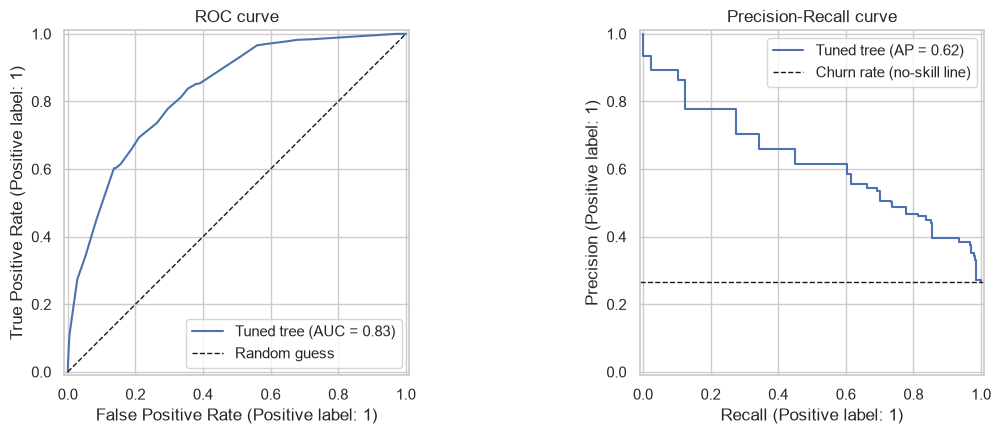

In [23]:
# Every metric above except these two depends on where the cutoff sits. ROC and precision-recall
# curves look at the ranking across all cutoffs, which is the fairer way to judge an imbalanced
# problem where 0.5 is an arbitrary place to draw the line.
print("ROC AUC: %.3f" % roc_auc_score(y_test, churn_probabilities))
print("PR  AUC: %.3f" % average_precision_score(y_test, churn_probabilities))

fig, (roc_axis, pr_axis) = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_predictions(y_test, churn_probabilities, ax=roc_axis, name='Tuned tree')
roc_axis.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')   # the do-nothing baseline
roc_axis.set_title('ROC curve')
roc_axis.legend(loc='lower right')

PrecisionRecallDisplay.from_predictions(y_test, churn_probabilities, ax=pr_axis, name='Tuned tree')
pr_axis.axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
                label='Churn rate (no-skill line)')
pr_axis.set_title('Precision-Recall curve')
pr_axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [24]:
## 8. Benchmarking against other model families
# A decision tree is what this project ships, but a score only means something next to
# alternatives. All three benchmarks train on the same encoded matrix as the tree, so nothing
# but the algorithm changes.

# Logistic regression is the one that needs scaling. TotalCharges runs into the thousands while
# the one-hot columns are 0/1, and without a scaler the solver has to work far harder to
# converge. The trees below are indifferent to scale, so they get the matrix as it is.
logistic_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
logistic_regression.fit(X_train_encoded, y_train)

random_forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
random_forest.fit(X_train_encoded, y_train)

gradient_boosting = GradientBoostingClassifier(random_state=42)
gradient_boosting.fit(X_train_encoded, y_train)

benchmark_comparison = pd.DataFrame([
    score_model('Decision Tree (tuned)', tuned_tree),
    score_model('Logistic Regression', logistic_regression),
    score_model('Random Forest', random_forest),
    score_model('Gradient Boosting', gradient_boosting)
]).round(3)

# Worth saying plainly rather than burying: logistic regression edges the tuned tree on most of
# these columns, and gradient boosting takes the best PR AUC. The gaps are a few points wide.
# The tree still ships, because a five-level tree can be printed, read and argued with by the
# retention team, and 200 forest trees cannot. That is a deliberate trade of a little accuracy
# for an explanation, not an oversight.
benchmark_comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Decision Tree (tuned),0.794,0.615,0.602,0.608,0.828,0.623
1,Logistic Regression,0.811,0.674,0.560,0.611,0.845,0.643
2,Random Forest,0.781,0.612,0.478,0.537,0.821,0.612
3,Gradient Boosting,0.795,0.647,0.503,0.566,0.841,0.648


In [25]:
## 9. Final model
# Section 5 compared three hand-built trees on the test set, section 6 redid that choice properly
# with cross-validation inside the training set, and section 7 checked whether class weighting was
# worth adopting. The tuned, unweighted tree comes out of all three.
final_model = tuned_tree

# Why this matters to the business:
# winning a new customer costs far more than keeping an existing one, so
#   - Proactive retention : reach the high-risk customers before they cancel
#   - Cost vs benefit     : a retention call is cheap, a lost contract is not
#   - Resource allocation : spend the retention budget on the accounts that are really at risk

print("Final model:", final_model)
print("Depth: %d | leaves: %d" % (final_model.get_depth(), final_model.get_n_leaves()))
print("Train accuracy: %.3f" % final_model.score(X_train_encoded, y_train))

final_predictions = final_model.predict(X_test_encoded)
print("\nConfusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, final_predictions))

# The grid search moved the numbers very little, which is itself the result: the hand-picked
# settings in section 4 were already close to the best this grid could find.
pd.DataFrame([
    score_model('DT2 - hand-picked (section 4)', tree_depth5),
    score_model('Tuned tree (section 6)', final_model)
]).round(3)


Final model: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=50,
                       random_state=42)
Depth: 5 | leaves: 32
Train accuracy: 0.801

Confusion matrix (rows = actual, columns = predicted):
[[1340  212]
 [ 223  338]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,DT2 - hand-picked (section 4),0.791,0.608,0.601,0.604,0.826,0.615
1,Tuned tree (section 6),0.794,0.615,0.602,0.608,0.828,0.623


Top 10 Features Influencing Churn:
                                 Feature  Importance
32         cat__Contract_Month-to-month    0.513872
42                    remainder__tenure    0.177485
12     cat__InternetService_Fiber optic    0.153570
39  cat__PaymentMethod_Electronic check    0.032125
46           remainder__AvgMonthlySpend    0.027030
44              remainder__TotalCharges    0.025033
23                  cat__TechSupport_No    0.023805
43            remainder__MonthlyCharges    0.016684
31             cat__StreamingMovies_Yes    0.007792
45           remainder__SpendPerService    0.007689

Top 10 Features Influencing Churn Graph:



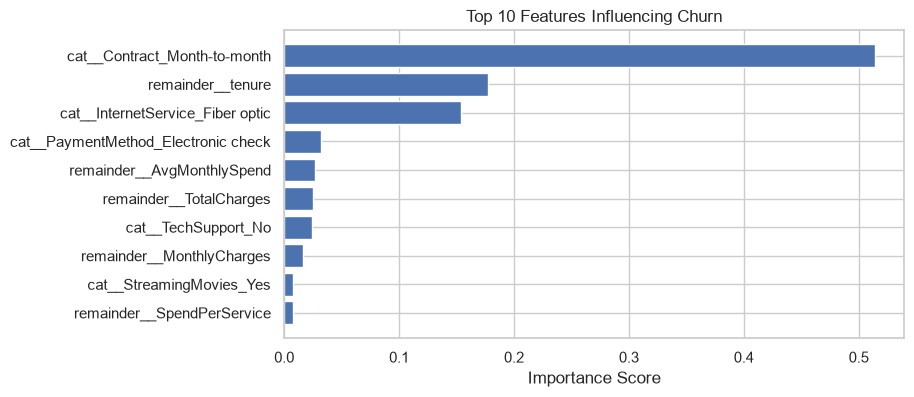

In [26]:
# 10. Model Interpretation - which columns is the tree actually leaning on?
importance_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'Importance': final_model.feature_importances_
})
top_10_features = importance_df.sort_values(by='Importance', ascending=False).head(10)
print("Top 10 Features Influencing Churn:\n", top_10_features)

# The same ranking as a chart, for a non-technical audience
print("\nTop 10 Features Influencing Churn Graph:\n")
plt.figure(figsize=(8, 4))
plt.barh(top_10_features['Feature'][::-1], top_10_features['Importance'][::-1])   # reversed so the strongest sits on top
plt.title('Top 10 Features Influencing Churn')
plt.xlabel('Importance Score')
plt.show()

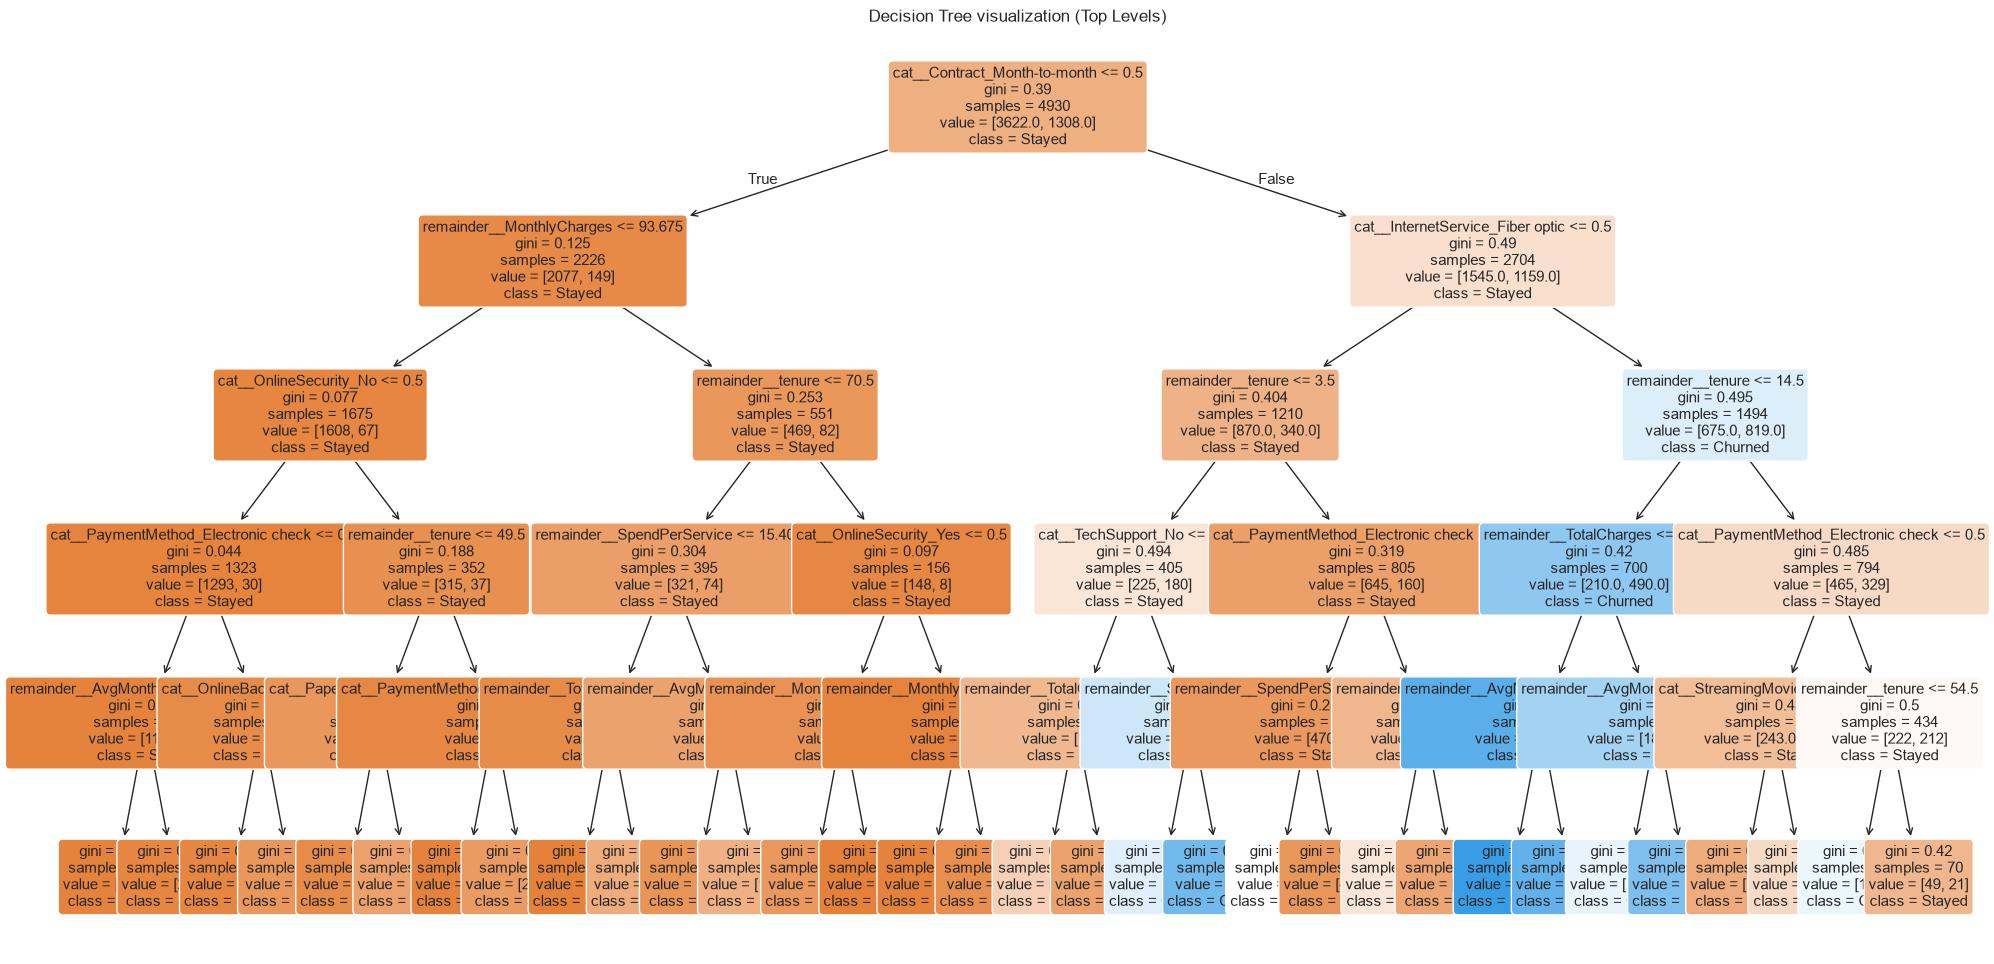

In [27]:
# The tree itself. Only the top levels are drawn - the full tree does not fit on one page,
# and the first few splits carry most of the signal.
plt.figure(figsize=(24, 12))
plot_tree(
    final_model,
    max_depth=5,
    feature_names=encoded_feature_names,
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title('Decision Tree visualization (Top Levels)')
plt.show()

In [28]:
## 11. Model Saving
# The API gets one object that does the whole job: engineer -> encode -> predict.
# Saving only the classifier would mean redoing the preprocessing in app.py, where any
# small difference would quietly change the predictions.
churn_model = Pipeline([
    ('feature_engineer', ChurnFeatureAdder()),
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

# Fit the whole thing on the raw training columns, the same shape the API receives
churn_model.fit(X_train, y_train)

model_path = os.path.join('..', 'model', 'churn_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)   # create model/ on a fresh checkout
joblib.dump(churn_model, model_path)
print("Unified churn_model saved successfully!")

Unified churn_model saved successfully!
